In [ ]:
!pip install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [4]:
#df_2  = pd.read_csv("/content/new_file.csv")

df_2 = pd.read_csv("/content/new_filtered_text_file.csv")
df_2

,diseases,text
0,panic disorder,"Patient presents with anxiety and nervousness,..."
1,panic disorder,"Patient presents with shortness of breath, dep..."
2,panic disorder,"Patient presents with anxiety and nervousness,..."
3,panic disorder,"Patient presents with anxiety and nervousness,..."
4,panic disorder,"Patient presents with anxiety and nervousness,..."
...,...,...
35078,fungal infection of the skin,"Patient presents with skin swelling, irregular..."
35079,fungal infection of the skin,"Patient presents with skin swelling, abnormal ..."
35080,fungal infection of the skin,"Patient presents with skin swelling, abnormal ..."
35081,fungal infection of the skin,"Patient presents with skin swelling, skin lesi..."


In [ ]:
df_2.isnull()

,diseases,text
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
35078,False,False
35079,False,False
35080,False,False
35081,False,False


old sample df but same dataset changed


In [5]:
#sample_df = df_2.sample(n=5000, random_state=42)

sample_df = pd.read_csv("/content/new_filter_sample_dataset.csv")

sample_df

,diseases,text
0,acute bronchospasm,"Patient presents with shortness of breath, che..."
1,panic disorder,"Patient presents with anxiety and nervousness,..."
2,acute pancreatitis,"Patient presents with sharp abdominal pain, vo..."
3,sciatica,"Patient presents with leg pain, hip pain, loss..."
4,degenerative disc disease,"Patient presents with back pain, shoulder pain..."
...,...,...
4995,asthma,"Patient presents with sharp chest pain, cough,..."
4996,cornea infection,"Patient presents with diminished vision, sympt..."
4997,transient ischemic attack,"Patient presents with dizziness, headache, wea..."
4998,spondylosis,"Patient presents with leg pain, arm pain, neck..."


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
sample_df["label"] = le.fit_transform(sample_df["diseases"])

print("Classes:", list(le.classes_))

Classes: ['actinic keratosis', 'acute bronchospasm', 'acute otitis media', 'acute pancreatitis', 'acute sinusitis', 'allergy', 'asthma', 'bipolar disorder', 'bursitis', 'chalazion', 'chronic obstructive pulmonary disease (copd)', 'chronic otitis media', 'chronic pain disorder', 'chronic sinusitis', 'complex regional pain syndrome', 'concussion', 'cornea infection', 'corneal disorder', 'degenerative disc disease', 'diverticulosis', 'fibromyalgia', 'fungal infection of the skin', 'hiatal hernia', 'hyperkalemia', 'hypoglycemia', 'infectious gastroenteritis', 'injury to the arm', 'injury to the trunk', 'marijuana abuse', 'neuralgia', 'pain after an operation', 'panic disorder', 'problem during pregnancy', 'pyelonephritis', 'sciatica', 'spondylosis', 'transient ischemic attack', 'vaginitis', 'vulvodynia']


In [ ]:
def row_to_text(row):
    symptoms = [col for col in sample_df.columns[1:-1] if row[col] == 1]  # skip 'diseases' and 'label'
    if not symptoms:
        return "No significant symptoms."
    return "Patient presents with: " + ", ".join(symptoms) + "."

sample_df["text"] = sample_df.apply(row_to_text, axis=1)

In [9]:
# BioBERT
Bio_BERT = "dmis-lab/biobert-base-cased-v1.1"

tokenizer = AutoTokenizer.from_pretrained(Bio_BERT)
model = AutoModel.from_pretrained(Bio_BERT)

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [10]:
# BioClinical BERT
Bio_Clinical_BERT = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(Bio_Clinical_BERT)
model_2 = AutoModel.from_pretrained(Bio_Clinical_BERT)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [ ]:
train_sample_df, test_sample_df = train_test_split(sample_df, test_size=0.2, stratify= sample_df["label"], random_state=42)
train_dataset = Dataset.from_pandas(train_sample_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_sample_df[["text", "label"]])

In [ ]:
models = {
    "BioBERT": Bio_BERT,
    "BioClinicalBERT": Bio_Clinical_BERT
}


def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Training loop
for name, model_name in models.items():
    print(f"\n===== Training {name} =====\n")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= sample_df["label"].nunique())

    def tokenize(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

    train_enc = train_dataset.map(tokenize, batched=True)
    test_enc = test_dataset.map(tokenize, batched=True)

    args = TrainingArguments(
        output_dir=f"./results_{name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir=f"./logs_{name}",
        logging_steps=50
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_enc,
        eval_dataset=test_enc,
        compute_metrics=compute_metrics
    )

    trainer.train()
    results = trainer.evaluate()
    print(f"{name} Results:", results)


===== Training BioBERT =====



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.650200,1.353254,0.842000,0.802236
2,0.865900,0.680588,0.917000,0.911935
3,0.648100,0.533639,0.936000,0.932375


BioClinicalBERT Results: {'eval_loss': 0.533639132976532, 'eval_accuracy': 0.936, 'eval_f1_macro': 0.932375354757115, 'eval_runtime': 7.3679, 'eval_samples_per_second': 135.724, 'eval_steps_per_second': 8.551, 'epoch': 3.0}


RUNTIME OF 5K SAMPLE ON CPU

In [5]:
df_2  = pd.read_csv("/content/new_filter_sample_dataset.csv")
df_2

,diseases,text
0,acute bronchospasm,"Patient presents with shortness of breath, che..."
1,panic disorder,"Patient presents with anxiety and nervousness,..."
2,acute pancreatitis,"Patient presents with sharp abdominal pain, vo..."
3,sciatica,"Patient presents with leg pain, hip pain, loss..."
4,degenerative disc disease,"Patient presents with back pain, shoulder pain..."
...,...,...
4995,asthma,"Patient presents with sharp chest pain, cough,..."
4996,cornea infection,"Patient presents with diminished vision, sympt..."
4997,transient ischemic attack,"Patient presents with dizziness, headache, wea..."
4998,spondylosis,"Patient presents with leg pain, arm pain, neck..."


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_2["label"] = le.fit_transform(df_2["diseases"])

In [7]:
train_df_2, test_df_2 = train_test_split(df_2, test_size=0.2, stratify= df_2["label"], random_state=42)
train_dataset = Dataset.from_pandas(train_df_2[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df_2[["text", "label"]])

In [11]:
models = {
    "BioBERT": Bio_BERT,
    "BioClinicalBERT": Bio_Clinical_BERT
}


def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Training loop
for name, model_name in models.items():
    print(f"\n===== Training {name} =====\n")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= df_2["label"].nunique())

    def tokenize(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

    train_enc = train_dataset.map(tokenize, batched=True)
    test_enc = test_dataset.map(tokenize, batched=True)

    args = TrainingArguments(
        output_dir=f"./results_{name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir=f"./logs_{name}",
        logging_steps=50
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_enc,
        eval_dataset=test_enc,
        compute_metrics=compute_metrics
    )

    trainer.train()
    results = trainer.evaluate()
    print(f"{name} Results:", results)


===== Training BioBERT =====



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.603200,1.322884,0.817000,0.760104
2,0.829900,0.652112,0.920000,0.918758
3,0.606000,0.515456,0.919000,0.916235


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


BioClinicalBERT Results: {'eval_loss': 0.5154563188552856, 'eval_accuracy': 0.919, 'eval_f1_macro': 0.9162352057258906, 'eval_runtime': 427.4537, 'eval_samples_per_second': 2.339, 'eval_steps_per_second': 0.147, 'epoch': 3.0}


Other code below

In [ ]:
class_counts = sample_df["label"].value_counts().sort_values()
print(class_counts.head(20))   # show the 20 rarest classes


In [ ]:
valid_labels = class_counts[class_counts >= 5].index

In [ ]:
label_counts = df["label"].value_counts()

# Show classes with very few samples
rare_classes = label_counts[label_counts < 2]
print(rare_classes)

In [ ]:
sample_df = sample_df[sample_df["label"].isin(valid_labels)].copy()
le = LabelEncoder()
sample_df["label"] = le.fit_transform(sample_df["label"])

In [ ]:
models = {
    "BioBERT": Bio_BERT,
    "BioClinicalBERT": Bio_Clinical_BERT
}


def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Training loop
for name, model_name in models.items():
    print(f"\n===== Training {name} =====\n")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=sample_df["label"].nunique())

    def tokenize(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

    train_enc = train_dataset.map(tokenize, batched=True)
    test_enc = test_dataset.map(tokenize, batched=True)

    args = TrainingArguments(
        output_dir=f"./results_{name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_dir=f"./logs_{name}",
        logging_steps=50
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_enc,
        eval_dataset=test_enc,
        compute_metrics=compute_metrics
    )

    trainer.train()
    results = trainer.evaluate()
    print(f"{name} Results:", results)

In [ ]:
train_sample_df, test_sample_df = train_test_split(sample_df, test_size=0.2, stratify= sample_df["label"], random_state=42)
train_dataset = Dataset.from_pandas(train_sample_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_sample_df[["text", "label"]])

BioDistil_BERT

In [3]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

In [4]:
tokenizer = AutoTokenizer.from_pretrained("nlpie/distil-biobert")
distilBioBERT = AutoModelForMaskedLM.from_pretrained("nlpie/distil-biobert")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/263M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("nlpie/distil-biobert")
distilBioBERT = AutoModelForSequenceClassification.from_pretrained("nlpie/distil-biobert", num_labels=len(sample_df["label"].unique()))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpie/distil-biobert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
num_labels = len(sample_df["label"].unique())
model = AutoModelForSequenceClassification.from_pretrained(
    "nlpie/distil-biobert",
    num_labels=num_labels
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpie/distil-biobert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    }


In [ ]:
training_args = TrainingArguments(
    output_dir="distilbiobert-results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro"
)

DISTIL BIO BERT

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()
results = trainer.evaluate()
print("DistilBioBERT Results:", results)

/tmp/ipython-input-4217299881.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lamatarek04 (lamatarek04-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,1.439341,0.716000,0.601452
2,1.947400,0.777132,0.864000,0.831776
3,1.947400,0.628058,0.884000,0.858944


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


DistilBioBERT Results: {'eval_loss': 0.6280578374862671, 'eval_accuracy': 0.884, 'eval_f1_macro': 0.8589443671516946, 'eval_runtime': 182.9135, 'eval_samples_per_second': 5.467, 'eval_steps_per_second': 0.344, 'epoch': 3.0}


Larger sample size and more epochs

In [6]:
df_2 = pd.read_csv('/content/new_filtered_text_file.csv')

sample_df_2 = df_2.sample(n=10000, random_state=42)

In [7]:
sample_df_2.to_csv('sample_file_10k.csv', index=False)

In [ ]:
sample_df_2

,diseases,text
30846,acute bronchospasm,"Patient presents with shortness of breath, che..."
40,panic disorder,"Patient presents with anxiety and nervousness,..."
5705,acute pancreatitis,"Patient presents with sharp abdominal pain, vo..."
31602,sciatica,"Patient presents with leg pain, hip pain, loss..."
32443,degenerative disc disease,"Patient presents with back pain, shoulder pain..."
...,...,...
11242,hyperkalemia,Patient presents with depressive or psychotic ...
34925,fungal infection of the skin,"Patient presents with abnormal appearing skin,..."
23901,vulvodynia,"Patient presents with sharp abdominal pain, na..."
6550,acute pancreatitis,"Patient presents with sharp chest pain, abusin..."


In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
sample_df_2["label"] = le.fit_transform(sample_df_2["diseases"])

print("Classes:", list(le.classes_))

Classes: ['actinic keratosis', 'acute bronchospasm', 'acute otitis media', 'acute pancreatitis', 'acute sinusitis', 'allergy', 'asthma', 'bipolar disorder', 'bursitis', 'chalazion', 'chronic obstructive pulmonary disease (copd)', 'chronic otitis media', 'chronic pain disorder', 'chronic sinusitis', 'complex regional pain syndrome', 'concussion', 'cornea infection', 'corneal disorder', 'degenerative disc disease', 'diverticulosis', 'fibromyalgia', 'fungal infection of the skin', 'hiatal hernia', 'hyperkalemia', 'hypoglycemia', 'infectious gastroenteritis', 'injury to the arm', 'injury to the trunk', 'marijuana abuse', 'neuralgia', 'pain after an operation', 'panic disorder', 'problem during pregnancy', 'pyelonephritis', 'sciatica', 'spondylosis', 'transient ischemic attack', 'vaginitis', 'vulvodynia']


In [9]:
train_sample_df_2, test_sample_df_2 = train_test_split(sample_df_2, test_size=0.2, stratify= sample_df_2["label"], random_state=42)
train_dataset = Dataset.from_pandas(train_sample_df_2[["text", "label"]])
test_dataset = Dataset.from_pandas(test_sample_df_2[["text", "label"]])

In [14]:
models = {
    "BioBERT": Bio_BERT,
    "BioClinicalBERT": Bio_Clinical_BERT
}


def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# Training loop
for name, model_name in models.items():
    print(f"\n===== Training {name} =====\n")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= sample_df_2["label"].nunique())

    def tokenize(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

    train_enc = train_dataset.map(tokenize, batched=True)
    test_enc = test_dataset.map(tokenize, batched=True)

    args = TrainingArguments(
        output_dir=f"./results_{name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=4, #4 epochs this time
        weight_decay=0.01,
        logging_dir=f"./logs_{name}",
        logging_steps=50
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_enc,
        eval_dataset=test_enc,
        compute_metrics=compute_metrics
    )

    trainer.train()
    results = trainer.evaluate()
    print(f"{name} Results:", results)


===== Training BioBERT =====



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.637600,0.467272,0.938500,0.937022
2,0.262300,0.222658,0.939500,0.937885
3,0.182900,0.186790,0.941000,0.937541
4,0.131700,0.178386,0.939000,0.936594


BioClinicalBERT Results: {'eval_loss': 0.17838631570339203, 'eval_accuracy': 0.939, 'eval_f1_macro': 0.9365940794027233, 'eval_runtime': 15.1341, 'eval_samples_per_second': 132.152, 'eval_steps_per_second': 8.259, 'epoch': 4.0}


Confusion Matrix and additional metrics


===== Additional Metrics for BioBERT =====



Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

BioBERT Additional Metrics:
  Recall (macro): 0.9353
  AUC: 0.9993
  Recall (micro): 0.9380
  Recall (weighted): 0.9380

BioBERT Classification Report:
              precision    recall  f1-score   support

     Class_0       0.96      1.00      0.98        50
     Class_1       0.75      0.88      0.81        56
     Class_2       1.00      1.00      1.00        35
     Class_3       1.00      0.97      0.99        70
     Class_4       0.96      0.86      0.91        50
     Class_5       1.00      0.98      0.99        51
     Class_6       0.83      0.80      0.81        54
     Class_7       1.00      0.90      0.95        41
     Class_8       1.00      1.00      1.00        72
     Class_9       1.00      0.97      0.99        38
    Class_10       0.82      0.73      0.77        51
    Class_11       1.00      0.92      0.96        36
    Class_12       1.00      0.85      0.92        41
    Class_13       0.83      1.00      0.91        34
    Class_14       0.99      0.93    

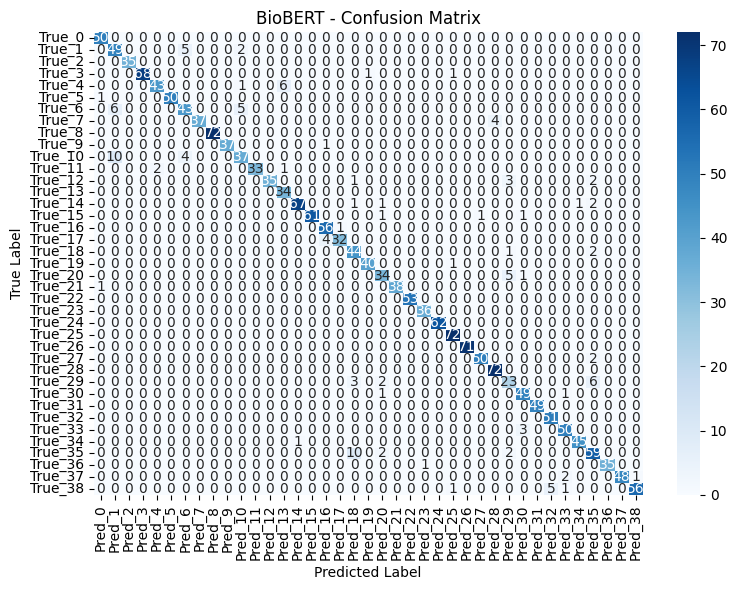



===== Additional Metrics for BioClinicalBERT =====



Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

BioClinicalBERT Additional Metrics:
  Recall (macro): 0.9364
  AUC: 0.9993
  Recall (micro): 0.9395
  Recall (weighted): 0.9395

BioClinicalBERT Classification Report:
              precision    recall  f1-score   support

     Class_0       0.96      1.00      0.98        50
     Class_1       0.90      0.80      0.85        56
     Class_2       1.00      0.97      0.99        35
     Class_3       1.00      0.97      0.99        70
     Class_4       0.96      0.88      0.92        50
     Class_5       1.00      0.98      0.99        51
     Class_6       0.76      0.93      0.83        54
     Class_7       0.91      0.98      0.94        41
     Class_8       1.00      1.00      1.00        72
     Class_9       1.00      0.97      0.99        38
    Class_10       0.78      0.71      0.74        51
    Class_11       0.97      0.97      0.97        36
    Class_12       0.97      0.85      0.91        41
    Class_13       0.87      0.97      0.92        34
    Class_14       1.

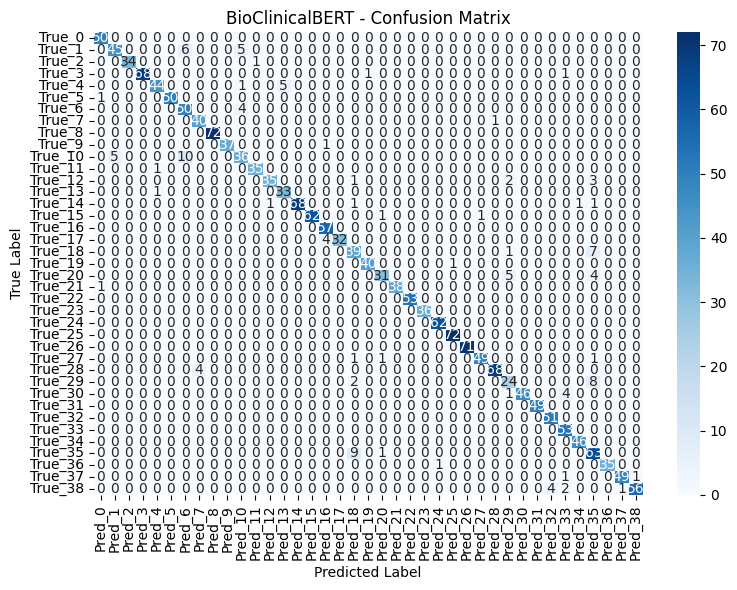

In [34]:

models = {
    "BioBERT": Bio_BERT,
    "BioClinicalBERT": Bio_Clinical_BERT
}

for name, model_name in models.items():
    print(f"\n===== Additional Metrics for {name} =====\n")


    config = AutoConfig.from_pretrained(model_name)
    config.num_labels = sample_df_2["label"].nunique()


    tokenizer = AutoTokenizer.from_pretrained(model_name) # Load tokenizer from original model name
    model = AutoModelForSequenceClassification.from_pretrained(f"./results_{name}/checkpoint-1000", config=config) # Load model with updated config and checkpoint weights


    def tokenize(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

    test_enc = test_dataset.map(tokenize, batched=True)


    trainer = Trainer(
        model=model,
        eval_dataset=test_enc,
    )

    # Get predictions
    predictions = trainer.predict(test_enc)

    # Extract predictions and labels
    logits = predictions.predictions
    labels = predictions.label_ids
    preds = np.argmax(logits, axis=1)


    probabilities = softmax(logits, axis=1)


    recall_macro = recall_score(labels, preds, average="macro")

    # Calculate AUC
    num_classes = len(np.unique(labels))
    if num_classes == 2:
        # Binary classification
       # auc = roc_auc_score(labels, probabilities[:, 1])
    else:

        auc = roc_auc_score(labels, probabilities, multi_class='ovr', average='macro')

    print(f"{name} Additional Metrics:")
    print(f"  Recall (macro): {recall_macro:.4f}")
    print(f"  AUC: {auc:.4f}")


    recall_micro = recall_score(labels, preds, average="micro")
    recall_weighted = recall_score(labels, preds, average="weighted")

    print(f"  Recall (micro): {recall_micro:.4f}")
    print(f"  Recall (weighted): {recall_weighted:.4f}")

    # per-class performance
    print(f"\n{name} Classification Report:")
    print("="*50)
    print(classification_report(labels, preds, target_names=[f"Class_{i}" for i in range(num_classes)]))


    cm = confusion_matrix(labels, preds)
    print(f"\n{name} Confusion Matrix:")
    print("="*30)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f"Pred_{i}" for i in range(num_classes)],
                yticklabels=[f"True_{i}" for i in range(num_classes)])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)

In [29]:
sample_df_2["label"].value_counts(normalize=True)

,proportion
label,
35,0.0367
14,0.0361
28,0.0361
8,0.0358
25,0.0358
26,0.0355
3,0.0349
15,0.0318
38,0.0314


In [24]:
print(results)

{'eval_loss': 0.17838631570339203, 'eval_accuracy': 0.939, 'eval_f1_macro': 0.9365940794027233, 'eval_runtime': 15.3622, 'eval_samples_per_second': 130.189, 'eval_steps_per_second': 8.137, 'epoch': 4.0}


In [ ]:
!ls

logs_BioBERT		    results_BioBERT	     sample_file_10k.csv
logs_BioClinicalBERT	    results_BioClinicalBERT  wandb
new_filtered_text_file.csv  sample_data


In [ ]:
!ls results_BioBERT/checkpoint-1000

config.json	   optimizer.pt   scheduler.pt	      training_args.bin
model.safetensors  rng_state.pth  trainer_state.json


In [ ]:
tokenizer.save_pretrained("results_BioBERT")

('results_BioBERT/tokenizer_config.json',
 'results_BioBERT/special_tokens_map.json',
 'results_BioBERT/vocab.txt',
 'results_BioBERT/added_tokens.json',
 'results_BioBERT/tokenizer.json')